
HackBio Stage Two

Reproduce a single-cell analysis pipleine using Scanpy and Anndata
Dataset is BoneMarrow.h5ad.

INSTALLATION OF LIBRARIES:
Scanpy
Anndata
igraph
Celltypist
Decoupler


In [ ]:
# Installation of Libraries
!pip install scanpy
!pip install anndata
!pip install igraph
!pip install celltypist
!pip install decoupler

In [ ]:
# import core tools
import scanpy as sc
import anndata as ad

In [ ]:
# Load raw data
!wget https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad

--2025-12-05 13:14:53--  https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 354509549 (338M) [application/octet-stream]
Saving to: ‘bone_marrow.h5ad.3’

bone_marrow.h5ad.3  100%[===================>] 338.09M  45.1MB/s    in 7.5s    

2025-12-05 13:15:00 (45.3 MB/s) - ‘bone_marrow.h5ad.3’ saved [354509549/354509549]



In [ ]:
# The dataset is loaded into an Anndata object
# This structure stores gene expression, metadata and embeddings
bone_marrow_adata = sc.read_h5ad('bone_marrow.h5ad')

In [ ]:
print(bone_marrow_adata)

AnnData object with n_obs × n_vars = 14783 × 17374
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'doi', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_tsne', 'X_umap'


In [ ]:
bone_marrow_adata.shape

(14783, 17374)

In [ ]:
bone_marrow_adata.var.head()

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding


In [ ]:
bone_marrow_adata.obs.head()

,disease stage,treatment,timepoint,Dataset,sample,disease_original,disease_general,COVID-19 Condition,Lineage,Cell.group,...,is_primary_data,suspension_type,tissue_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep2,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Myeloid,CD14+ Monocyte,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,2P)e%zgsv_
Guo-AAACCTGAGAGGTTGC-7,remission,400 mg Tocilizumab at day 1,day 7,Guo et al._Nature Communication,Guo_P2-day7,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD8+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,78-year-old stage,Lv&N1yD6*0
Guo-AAACCTGAGATACACA-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,DZ>`^5OH2o
Guo-AAACCTGAGCGATTCT-1,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep1,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Lymphoid_T/NK,CD8+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,J4$QmqEgvX
Guo-AAACCTGAGTGAAGAG-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,Y&7u#&E`-T


In [ ]:
# Assign to DataFrame
bone_marrow_adata.to_df()

,ENSG00000161920,ENSG00000122335,ENSG00000175548,ENSG00000100330,ENSG00000176340,ENSG00000179846,ENSG00000204860,ENSG00000172260,ENSG00000141424,ENSG00000164512,...,ENSG00000164114,ENSG00000151702,ENSG00000224578,ENSG00000138756,ENSG00000111052,ENSG00000176946,ENSG00000150456,ENSG00000284934,ENSG00000261842,ENSG00000260456
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,0.0,0.000000,0.0,0.0,9.436466,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGAGGTTGC-7,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,8.817776,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGATACACA-3,0.0,8.651494,0.0,0.0,8.651494,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGCGATTCT-1,0.0,0.000000,0.0,0.0,8.858533,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGTGAAGAG-3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guo-TTTGTCAGTTTCGCTC-4,0.0,0.000000,0.0,0.0,8.389465,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-TTTGTCATCAGAGACG-7,0.0,0.000000,0.0,0.0,9.931639,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-TTTGTCATCAGATAAG-4,0.0,0.000000,0.0,0.0,10.009642,0.0,0.0,0.0,0.000000,0.0,...,0.0,9.01104,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


QUALITY CONTROL: To keep high quality cells and informative genes

In [ ]:
# Basic Quality Control Filtering
# Cells expressing too few genes are likely empty droplets
bone_marrow_adata.var_names_make_unique()
bone_marrow_adata.obs_names_make_unique()

In [ ]:
bone_marrow_adata.var['MT'] = bone_marrow_adata.var['feature_name'].str.startswith('MT-')
bone_marrow_adata.var['RIBO'] = bone_marrow_adata.var['feature_name'].str.startswith(('RPS', 'RPL'))
bone_marrow_adata.var['HB'] = bone_marrow_adata.var['feature_name'].str.contains('^HB[^(P)]')

In [ ]:
mt_genes = bone_marrow_adata.var[bone_marrow_adata.var['MT']]
mt_genes

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB
ENSG00000228253,2270,False,MT-ATP8,NCBITaxon:9606,gene,207,protein_coding,True,False,False
ENSG00000198899,15626,False,MT-ATP6,NCBITaxon:9606,gene,681,protein_coding,True,False,False
ENSG00000198763,15561,False,MT-ND2,NCBITaxon:9606,gene,1042,protein_coding,True,False,False
ENSG00000198886,15656,False,MT-ND4,NCBITaxon:9606,gene,1378,protein_coding,True,False,False
ENSG00000198804,15656,False,MT-CO1,NCBITaxon:9606,gene,1542,protein_coding,True,False,False
ENSG00000198695,4611,False,MT-ND6,NCBITaxon:9606,gene,525,protein_coding,True,False,False
ENSG00000212907,6575,False,MT-ND4L,NCBITaxon:9606,gene,297,protein_coding,True,False,False
ENSG00000198888,14520,False,MT-ND1,NCBITaxon:9606,gene,956,protein_coding,True,False,False
ENSG00000198712,15669,False,MT-CO2,NCBITaxon:9606,gene,684,protein_coding,True,False,False
ENSG00000198727,15393,False,MT-CYB,NCBITaxon:9606,gene,1141,protein_coding,True,False,False


In [ ]:
sc.pp.calculate_qc_metrics(
bone_marrow_adata, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True)


In [ ]:
bone_marrow_adata.obs.head()

,disease stage,treatment,timepoint,Dataset,sample,disease_original,disease_general,COVID-19 Condition,Lineage,Cell.group,...,pct_counts_in_top_500_genes,total_counts_MT,log1p_total_counts_MT,pct_counts_MT,total_counts_RIBO,log1p_total_counts_RIBO,pct_counts_RIBO,total_counts_HB,log1p_total_counts_HB,pct_counts_HB
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep2,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Myeloid,CD14+ Monocyte,...,40.537370,138.356339,4.937034,1.154665,879.968079,6.781022,7.343850,0.000000,0.000000,0.000000
Guo-AAACCTGAGAGGTTGC-7,remission,400 mg Tocilizumab at day 1,day 7,Guo et al._Nature Communication,Guo_P2-day7,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD8+ T cell,...,57.850376,113.859787,4.743712,1.350507,914.212402,6.819156,10.843602,0.000000,0.000000,0.000000
Guo-AAACCTGAGATACACA-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,59.749640,125.068520,4.836825,1.543431,952.813843,6.860468,11.758374,18.301193,2.960167,0.225849
Guo-AAACCTGAGCGATTCT-1,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep1,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Lymphoid_T/NK,CD8+ T cell,...,56.156243,103.474380,4.648942,1.182754,924.013672,6.829809,10.561848,0.000000,0.000000,0.000000
Guo-AAACCTGAGTGAAGAG-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,100.000121,138.531082,4.938287,2.870118,850.272156,6.746732,17.616129,0.000000,0.000000,0.000000


In [ ]:
bone_marrow_adata.var.head()

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding,False,False,False,885,0.502831,0.407351,94.013394,7433.353516,8.913867
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding,False,False,False,405,0.231814,0.208488,97.260367,3426.911377,8.139707
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding,False,False,False,142,0.082084,0.078889,99.039437,1213.443970,7.102042
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding,False,False,False,404,0.227307,0.204822,97.267131,3360.278564,8.120077
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding,False,False,False,6898,4.277597,1.663471,53.338294,63235.750000,11.054641


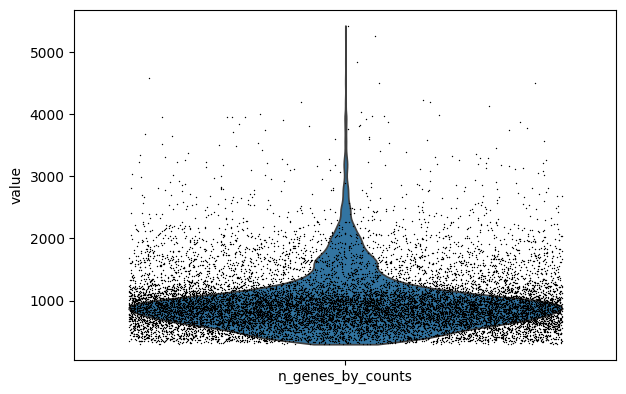

In [ ]:
# number of genes in cells
sc.pl.violin(
    bone_marrow_adata,
    ["n_genes_by_counts"],
    jitter=0.4,
    multi_panel=False,
)

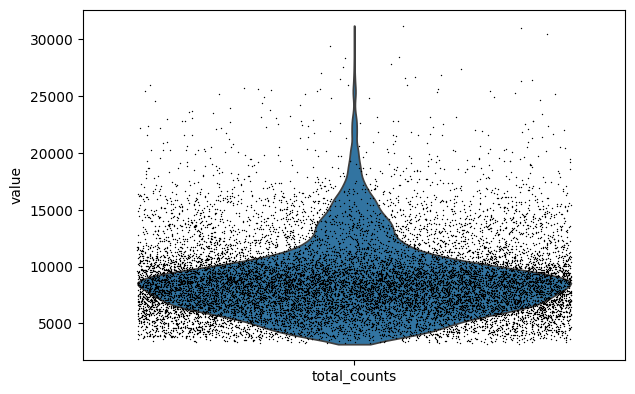

In [ ]:
# Total counts of genes
sc.pl.violin(
    bone_marrow_adata,
    ["total_counts"],
    jitter=0.4,
    multi_panel=False,
)

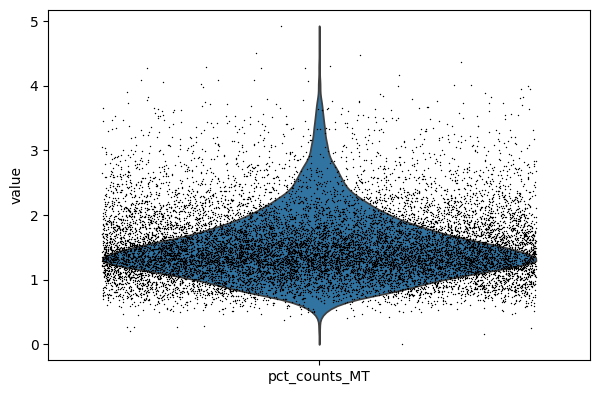

In [ ]:
# Mitochondrial genes
sc.pl.violin(
    bone_marrow_adata,
    ["pct_counts_MT"],
    jitter=0.4,
    multi_panel=False,
)

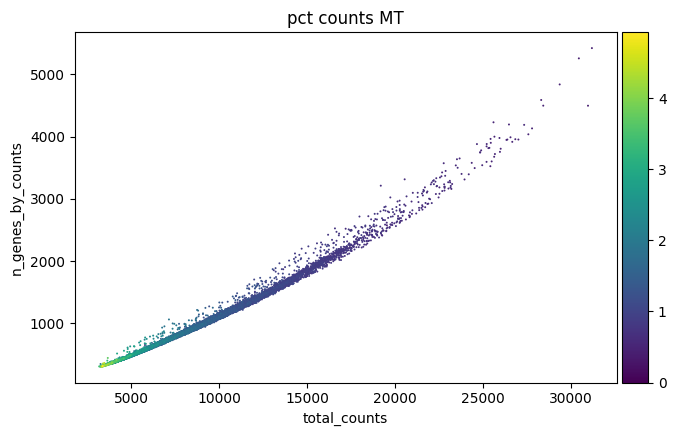

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

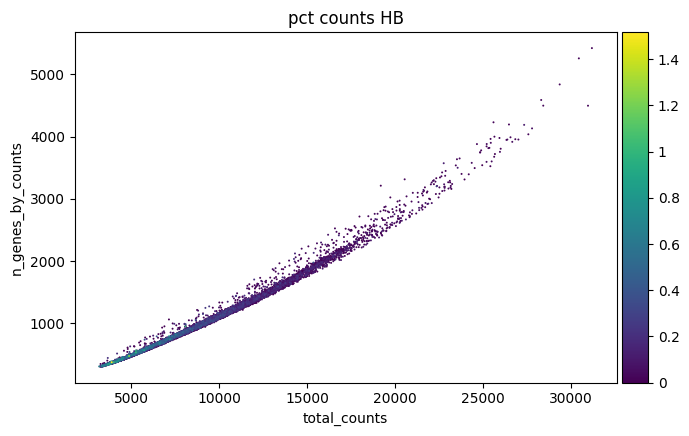

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_HB")

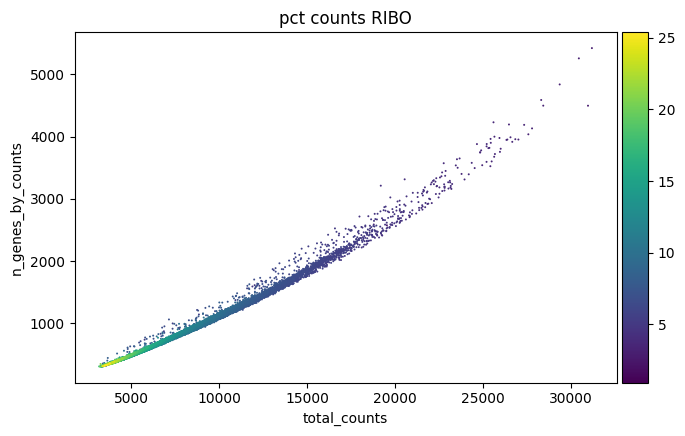

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_RIBO")

In [ ]:
bone_marrow_adata = bone_marrow_adata[
    bone_marrow_adata.obs['pct_counts_RIBO'] < 10]

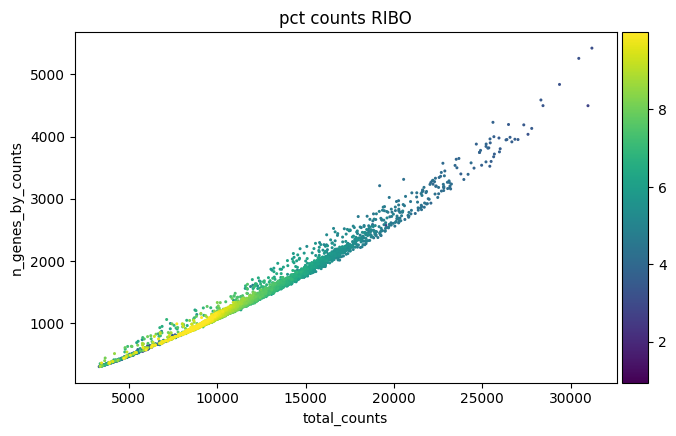

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color = "pct_counts_RIBO")

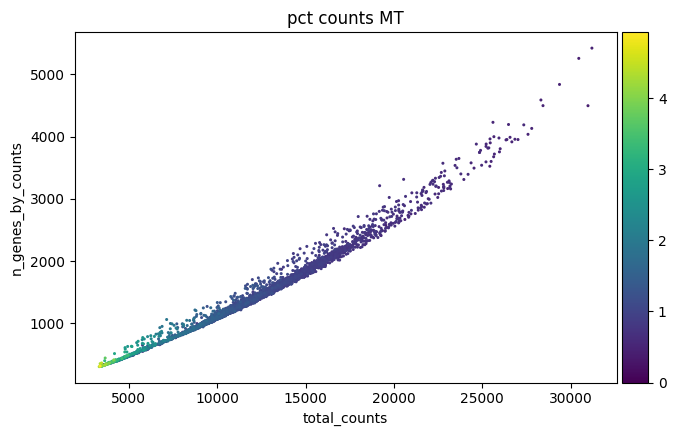

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

In [ ]:
sc.pp.scrublet(bone_marrow_adata) #doublet detection

NORMALIZATION

In [ ]:
# Normalize counts so each cell has equivalent total expression
bone_marrow_adata.layers["counts"] = bone_marrow_adata.X.copy()


In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(bone_marrow_adata)
# Logarithmize the data
sc.pp.log1p(bone_marrow_adata)

In [ ]:
# Highly variable genes
# HVGs retain biologically informative genes
sc.pp.highly_variable_genes(bone_marrow_adata, n_top_genes=1000)

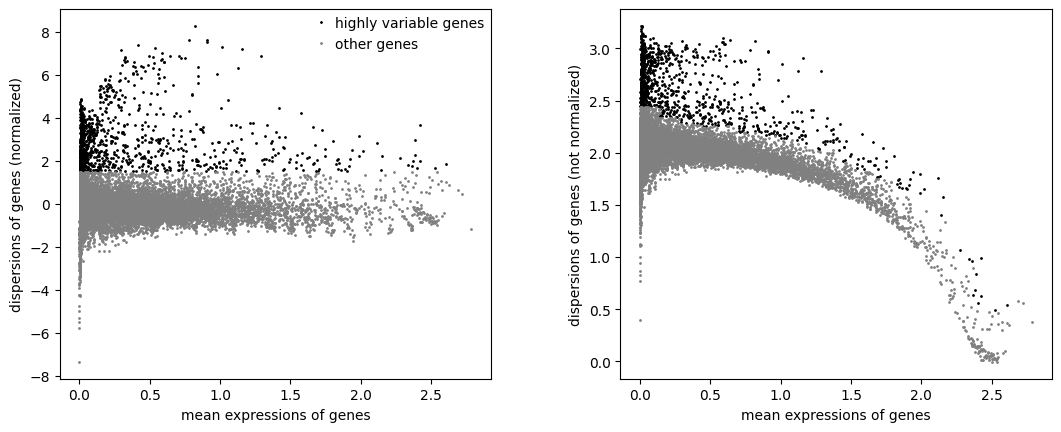

In [ ]:
sc.pl.highly_variable_genes(bone_marrow_adata )

Dimensionality Reduction: Principal Component Analysis, UMAP. Non Linear Dimensionality Reduction: Leiden

In [ ]:
# Principal Component Analysis
sc.tl.pca(bone_marrow_adata)

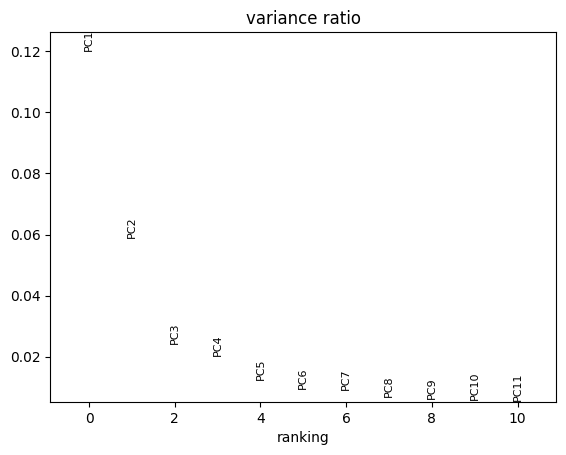

In [ ]:
sc.pl.pca_variance_ratio(bone_marrow_adata, n_pcs=10, log=False)

In [ ]:
# Neighbor Graph and Clustering
sc.pp.neighbors(bone_marrow_adata)

In [ ]:
sc.tl.umap(bone_marrow_adata)

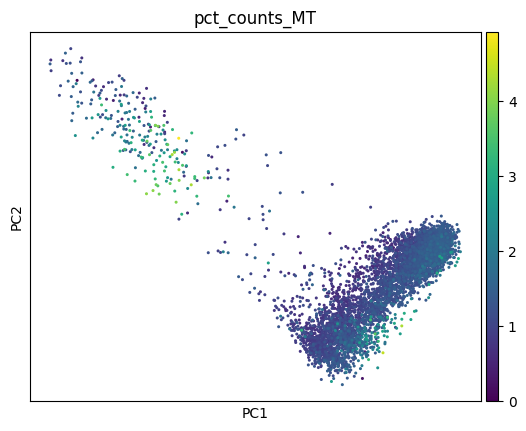

In [ ]:
sc.pl.pca(
    bone_marrow_adata,
    color=["pct_counts_MT"]
)

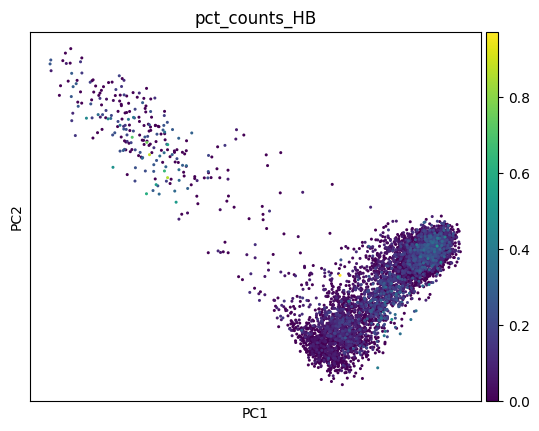

In [ ]:
sc.pl.pca(
    bone_marrow_adata,
    color=["pct_counts_HB"]
)

In [ ]:
# UMAP Visualization
sc.tl.umap(bone_marrow_adata)

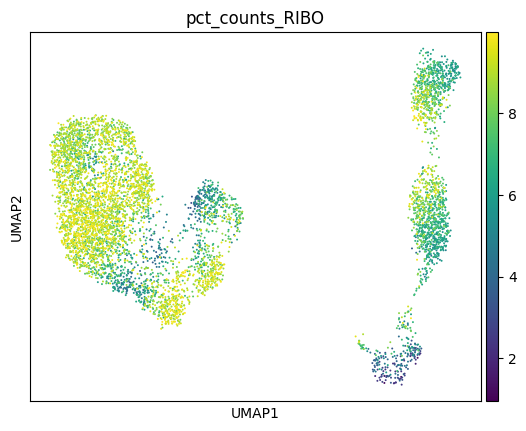

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["pct_counts_RIBO"],
    size=8,
)

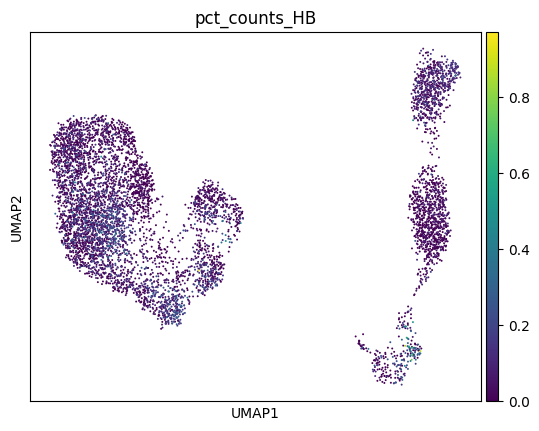

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["pct_counts_HB"],
    size=8,
)

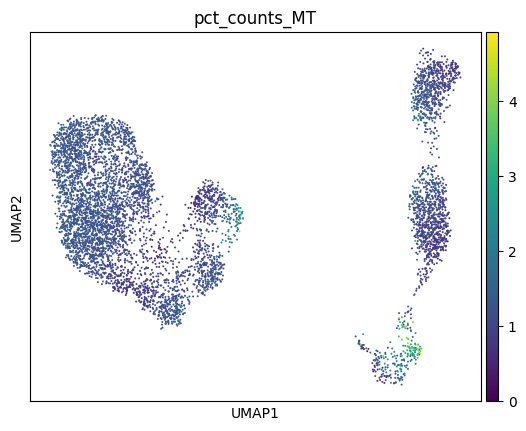

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["pct_counts_MT"],
    size=8,
)

In [ ]:
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2)

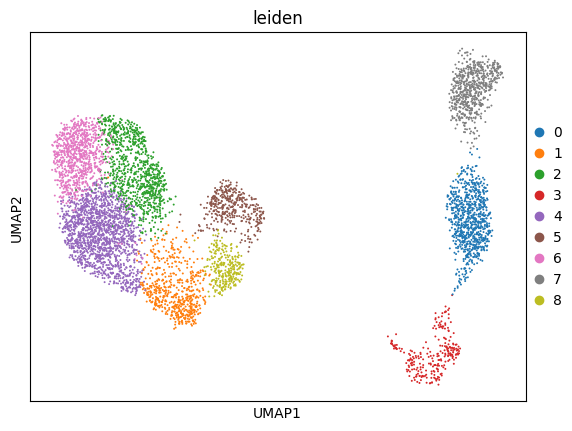

In [ ]:
# Leiden Clustering: detects communities representing cell types
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden"],
    size=8,
)


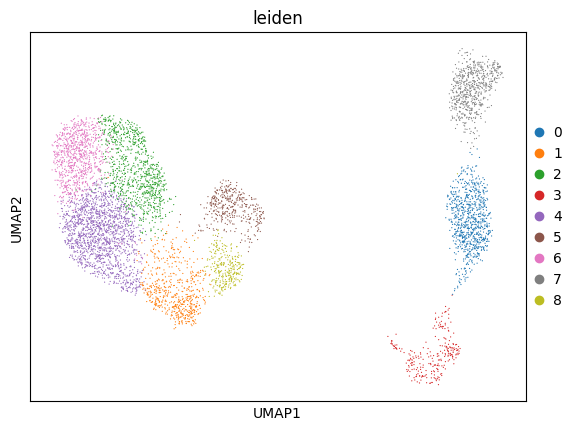

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

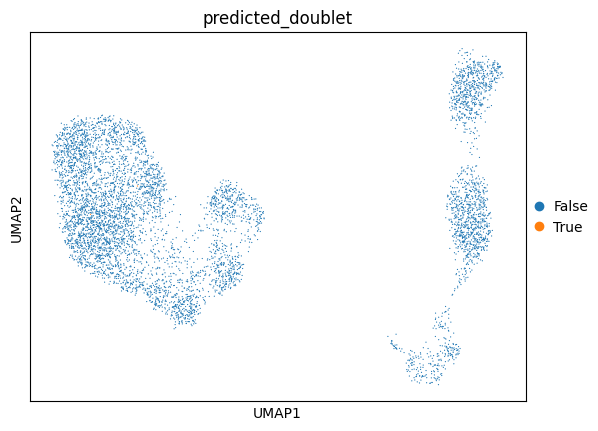

In [ ]:
# Doublet Visualization
sc.pl.umap(
    bone_marrow_adata,
    color=["predicted_doublet"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

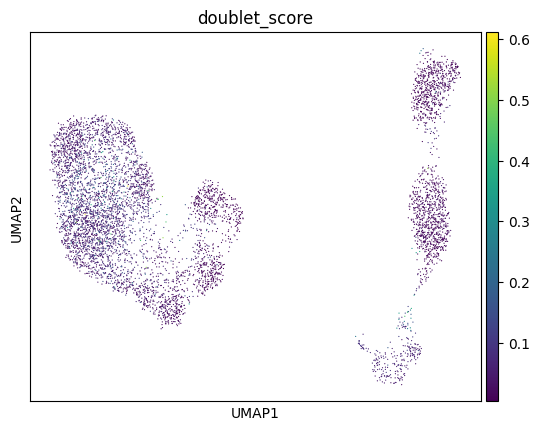

In [ ]:
# UMAP of Doublet
sc.pl.umap(
    bone_marrow_adata,
    color=[ "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

In [ ]:
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2, key_added="leiden_res0_02", resolution=0.02)
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2, key_added="leiden_res2", resolution=2)

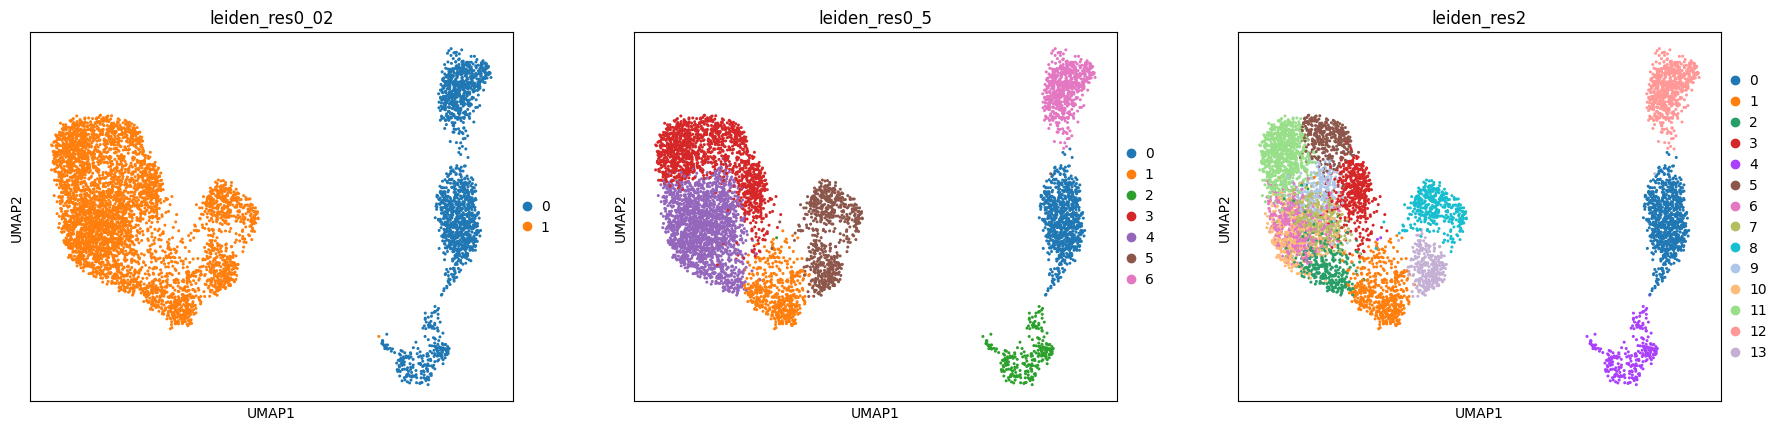

In [ ]:
# Clustering at resolutions of 0.02, 0.5, and 2
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden_res0_02", "leiden_res0_5", "leiden_res2"],
)

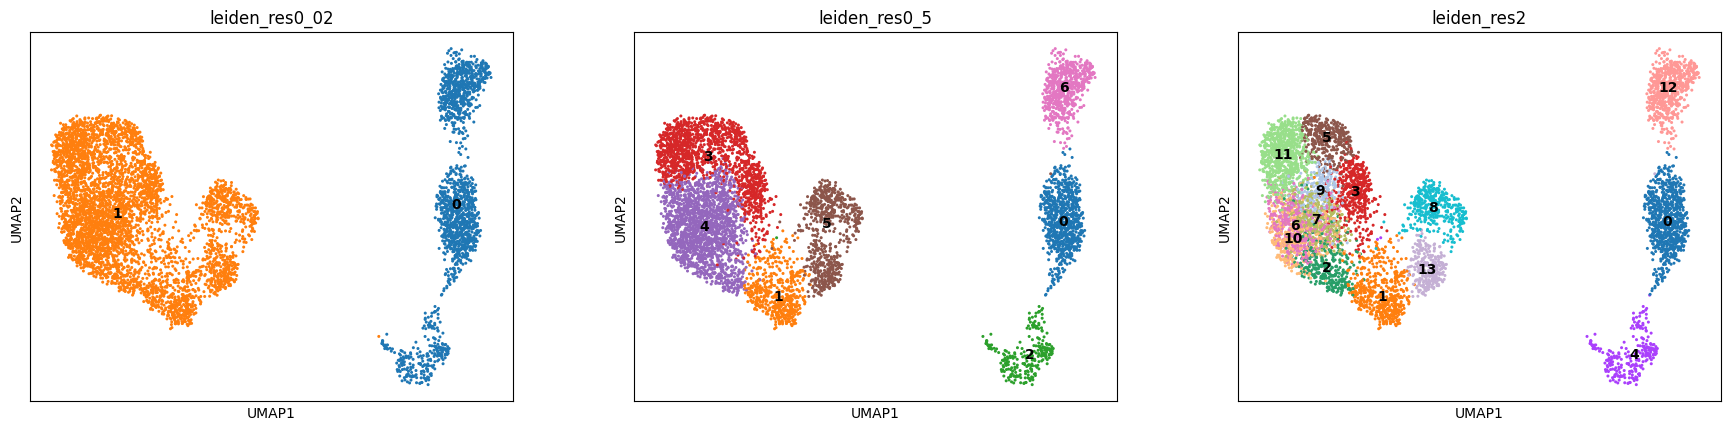

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden_res0_02", "leiden_res0_5", "leiden_res2"],
    legend_loc="on data"
)

Cell Type Annotation

In [ ]:
import pandas as pd
import celltypist as ct
import decoupler as dc

In [ ]:
!wget wget -O result.txt 'http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query><Query  virtualSchemaName = "default" formatter = "CSV" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" ><Dataset name = "hsapiens_gene_ensembl" interface = "default" ><Attribute name = "ensembl_gene_id" /><Attribute name = "external_gene_name" /></Dataset></Query>'
#this downloads the table of genes directly from ensemble

--2025-12-05 13:16:49--  http://wget/
Resolving wget (wget)... failed: Name or service not known.
wget: unable to resolve host address ‘wget’
--2025-12-05 13:16:49--  http://www.ensembl.org/biomart/martservice?query=%3C?xml%20version=%221.0%22%20encoding=%22UTF-8%22?%3E%3C!DOCTYPE%20Query%3E%3CQuery%20%20virtualSchemaName%20=%20%22default%22%20formatter%20=%20%22CSV%22%20header%20=%20%220%22%20uniqueRows%20=%20%220%22%20count%20=%20%22%22%20datasetConfigVersion%20=%20%220.6%22%20%3E%3CDataset%20name%20=%20%22hsapiens_gene_ensembl%22%20interface%20=%20%22default%22%20%3E%3CAttribute%20name%20=%20%22ensembl_gene_id%22%20/%3E%3CAttribute%20name%20=%20%22external_gene_name%22%20/%3E%3C/Dataset%3E%3C/Query%3E
Resolving www.ensembl.org (www.ensembl.org)... 193.62.193.83
Connecting to www.ensembl.org (www.ensembl.org)|193.62.193.83|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘result.txt’

result.txt              [      <=>      

In [ ]:
ensembl_var = pd.read_csv('result.txt', header = None)

ensembl_var.columns = ['ensembl_gene_id', 'gene_name']

ensembl_var.head()

,ensembl_gene_id,gene_name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [ ]:
# Query Omnipath and get PanglaoDB
markers = dc.op.resource(name="PanglaoDB", organism="human")

# Keep canonical cell type markers alone
markers = markers[markers["canonical_marker"]]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

#Format because dc only accepts cell_type and genesymbol
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]
markers.head()

,source,target
,,
2,Bergmann glia,A2M
4,Mast cells,A4GALT
5,Embryonic stem cells,A7KBS4
8,Pinealocytes,AANAT
9,Astrocytes,AANAT


In [ ]:
#correct target to ensemble
markers = markers.merge(ensembl_var, left_on="target", right_on="gene_name", how="left")
markers = markers.drop(columns=["target"])
# Remove duplicated entries
markers = markers[~markers.duplicated(["source", "ensembl_gene_id"])]

#Format because dc only accepts cell_type and genesymbol
markers = markers.rename(columns={"source": "source", "ensembl_gene_id": "target"})

markers = markers[["source", "target"]]
markers = markers.dropna()

markers.head()

,source,target
0,Bergmann glia,ENSG00000175899
1,Mast cells,ENSG00000128274
3,Pinealocytes,ENSG00000129673
4,Astrocytes,ENSG00000129673
5,Sertoli cells,ENSG00000205002


In [ ]:
dc.mt.ulm(data=bone_marrow_adata, net=markers, tmin=3)

In [ ]:
bone_marrow_adata.obsm["score_ulm"]

,Acinar cells,Adipocytes,Adrenergic neurons,Airway goblet cells,Alpha cells,Alveolar macrophages,Astrocytes,B cells,B cells memory,B cells naive,...,T follicular helper cells,T helper cells,T memory cells,T regulatory cells,Tanycytes,Taste receptor cells,Thymocytes,Trophoblast cells,Tuft cells,Urothelial cells
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,0.869681,0.046776,-0.593696,-0.663793,0.833040,0.835060,0.275245,1.465806,-0.314043,0.225692,...,-0.514140,-0.423875,1.637265,-0.004777,0.535754,0.414003,-0.547459,-0.514140,3.110482,-0.785460
Guo-AAACCTGCACACCGCA-4,-1.074275,-0.713683,-0.554564,-0.620040,1.033052,-0.733687,1.566605,6.608665,6.752643,8.477642,...,-0.480251,1.541764,4.153811,-0.960771,-0.784369,0.553327,2.072010,1.703997,1.190943,-0.733687
Guo-AAACCTGCACGACTCG-6,-0.678539,-1.370219,-0.350282,-0.391638,0.894091,-0.463420,-0.084869,-1.176316,-0.529276,-0.529276,...,-0.303344,-0.743369,-0.303344,-0.606850,3.667302,-0.495432,0.462493,-0.303344,0.368873,-0.463420
Guo-AAACCTGCATCCAACA-3,-1.005773,-0.486785,-0.519203,-0.580504,1.174259,1.051015,0.506126,0.782689,1.297566,0.320631,...,-0.449629,0.891687,2.025982,0.259325,-0.734354,-0.734354,2.353831,-0.449629,0.486132,-0.686904
Guo-AAACCTGGTTCAGGCC-4,0.469381,-0.751977,1.015647,-0.717219,-1.200482,0.556967,-0.178923,0.495743,0.352079,0.443952,...,-0.555520,0.983135,1.614808,-0.154378,-0.907305,-0.907305,0.700195,1.357944,0.701857,-0.848680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guo-TTTGTCAGTTCCGGCA-7,-1.045011,-0.614805,-0.539458,-0.603151,1.114757,0.975763,0.398504,0.649359,-0.445542,1.613430,...,-0.467170,0.688049,1.967496,-0.934600,-0.763003,0.611261,1.487475,1.776803,2.073840,0.755408
Guo-TTTGTCAGTTCGTCTC-4,-1.053570,-1.632881,-0.543876,-0.608091,0.013297,2.384317,-0.346322,1.851275,0.539105,1.573616,...,-0.470996,1.655530,1.995491,0.171400,-0.769252,-0.769252,1.354695,-0.470996,2.091987,-0.719547
Guo-TTTGTCAGTTTCGCTC-4,-1.008223,-1.007905,-0.520468,-0.581919,0.144849,0.999742,0.499339,3.187443,1.827482,2.384286,...,-0.450724,-0.159518,2.087005,-0.901699,-0.736143,-0.736143,2.307135,-0.450724,1.397603,-0.688578


In [ ]:
score = dc.pp.get_obsm(bone_marrow_adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 6322 × 126
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO', 'log1p_total_counts_RIBO', 'p

In [ ]:
bone_marrow_adata.obsm["score_ulm"].columns

Index(['Acinar cells', 'Adipocytes', 'Adrenergic neurons',
       'Airway goblet cells', 'Alpha cells', 'Alveolar macrophages',
       'Astrocytes', 'B cells', 'B cells memory', 'B cells naive',
       ...
       'T follicular helper cells', 'T helper cells', 'T memory cells',
       'T regulatory cells', 'Tanycytes', 'Taste receptor cells', 'Thymocytes',
       'Trophoblast cells', 'Tuft cells', 'Urothelial cells'],
      dtype='object', length=126)

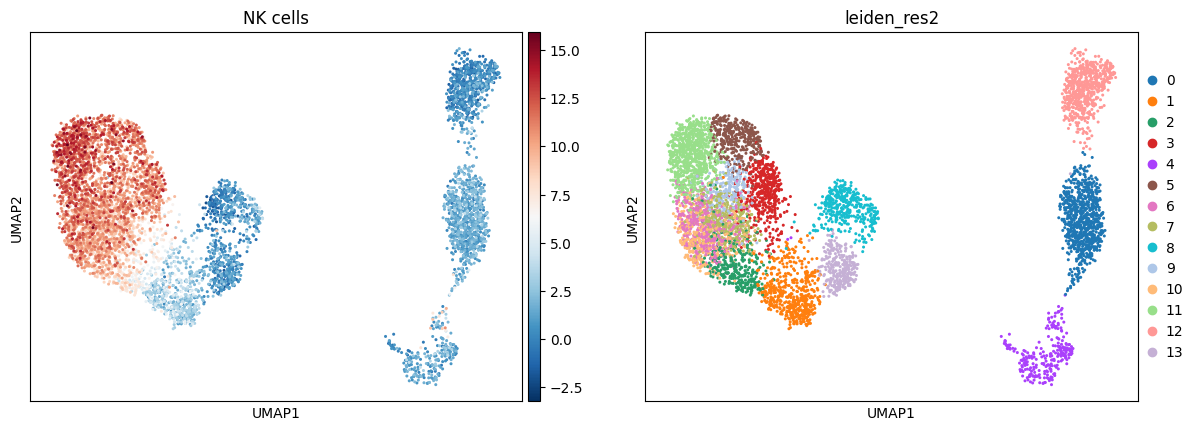

In [ ]:
# Natural Killer cells
sc.pl.umap(score,  color=["NK cells", "leiden_res2"], cmap="RdBu_r")

In [ ]:
import seaborn as sns

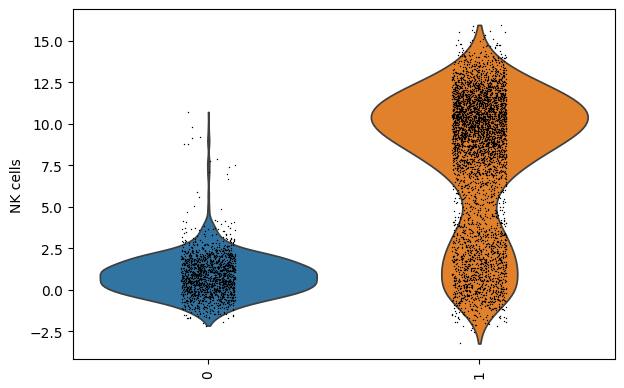

In [ ]:
sc.pl.violin(score, keys=["NK cells"], groupby="leiden_res0_02", rotation=90)

In [ ]:
bone_marrow_adata_rank = dc.tl.rankby_group(score, groupby="leiden_res0_5", reference="rest", method="t-test_overestim_var")
bone_marrow_adata_rank = bone_marrow_adata_rank[bone_marrow_adata_rank["stat"] > 0]
bone_marrow_adata_rank

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,Neutrophils,81.392727,6.086790,0.000000,0.000000
1,0,rest,Macrophages,69.094608,5.534838,0.000000,0.000000
2,0,rest,Dendritic cells,62.668676,5.088771,0.000000,0.000000
3,0,rest,Monocytes,58.931068,5.353865,0.000000,0.000000
4,0,rest,Microglia,56.634925,3.610113,0.000000,0.000000
...,...,...,...,...,...,...,...
869,6,rest,Eosinophils,0.873882,0.038960,0.382354,0.422602
874,6,rest,Ependymal cells,0.596495,0.015913,0.550952,0.583361
876,6,rest,Keratinocytes,0.430784,0.023467,0.666699,0.694249
877,6,rest,Adrenergic neurons,0.392471,0.010674,0.694778,0.714902


In [ ]:
# Cluster Annotation
cluster_annotations = bone_marrow_adata_rank[bone_marrow_adata_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


In [ ]:
cluster_annotations

{'0': 'Neutrophils',
 '1': 'Nuocytes',
 '2': 'Platelets',
 '3': 'NK cells',
 '5': 'Plasma cells',
 '4': 'T cells',
 '6': 'Monocytes'}

In [ ]:
bone_marrow_adata.obs['cell_type'] = bone_marrow_adata.obs['leiden_res0_5'].map(cluster_annotations)

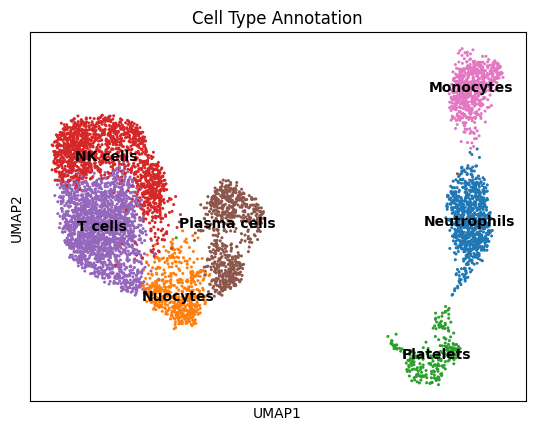

In [ ]:
sc.pl.umap(bone_marrow_adata, color='cell_type', legend_loc='on data', title='Cell Type Annotation')


In [ ]:
# Example of how to subset for multiple genes in the 'source' column
# Ensure available_genes contains Ensembl IDs as they are used in adata.var_names
# Fix: Use bone_marrow_adata.var_names which contains the unique-ified gene symbols
available_genes = set(bone_marrow_adata.var_names)

NK_cells_markers = markers[markers['source'].isin(['NK cells'])]['target']
NK_cells_markers = NK_cells_markers[NK_cells_markers.isin(available_genes)]

T_cells_markers = markers[markers['source'].isin(['T cells'])]['target']
T_cells_markers = T_cells_markers[T_cells_markers.isin(available_genes)]

Plasma_cells_markers = markers[markers['source'].isin(['Plasma cells'])]['target']
Plasma_cells_markers = Plasma_cells_markers[Plasma_cells_markers.isin(available_genes)]

Platelets_markers = markers[markers['source'].isin(['Platelets'])]['target']
Platelets_markers = Platelets_markers[Platelets_markers.isin(available_genes)]

Nuocytes_markers = markers[markers['source'].isin(['Nuocytes'])]['target']
Nuocytes_markers = Nuocytes_markers[Nuocytes_markers.isin(available_genes)]

Neutrophil_markers = markers[markers['source'].isin(['Neutrophils'])]['target']
Neutrophil_markers = Neutrophil_markers[Neutrophil_markers.isin(available_genes)]

Monocytes_markers = markers[markers['source'].isin(['Monocytes'])]['target']
Monocytes_markers = Monocytes_markers[Monocytes_markers.isin(available_genes)]

In [ ]:
display(Neutrophil_markers)

,target
73,ENSG00000151651
123,ENSG00000159322
396,ENSG00000081181
439,ENSG00000244617
559,ENSG00000109743
592,ENSG00000197405
702,ENSG00000277632
751,ENSG00000163823
781,ENSG00000121797
787,ENSG00000170458


In [ ]:
marker_genes_dict = {
    "T cells": T_cells_markers.head().tolist(),
    "Nuocytes": Nuocytes_markers.head().tolist(),
    "Neutrophils": Neutrophil_markers.head().tolist(),
    "Monocytes": Monocytes_markers.head().tolist(),
    "Platelets": Platelets_markers.head().tolist(),
    "Plasma cells": Plasma_cells_markers.head().tolist(),
    "NK cells": NK_cells_markers.head().tolist(),
    }

categories: 0, 1, 2, etc.
var_group_labels: T cells, Nuocytes, Neutrophils, etc.


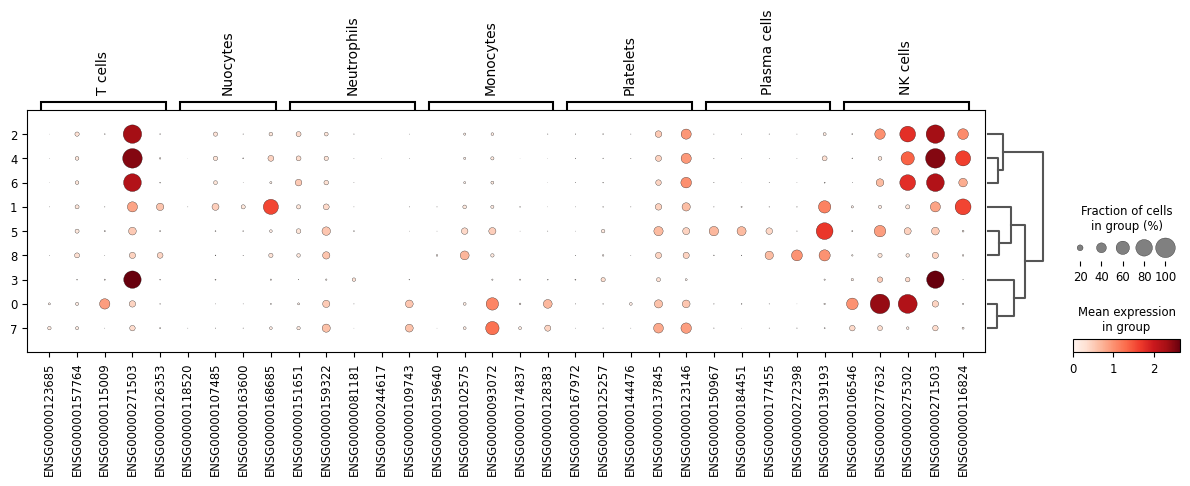

In [ ]:
# Generate the dot plot
sc.pl.dotplot(
    bone_marrow_adata,
    var_names=marker_genes_dict, # Use the dictionary for grouped genes
    groupby='leiden', # Or whatever column holds your cell clusters (e.g., 'clusters', 'cell_type')
    dendrogram=True, # Set to True if you want to cluster the genes/groups
    color_map='Reds',
    use_raw=False,
)

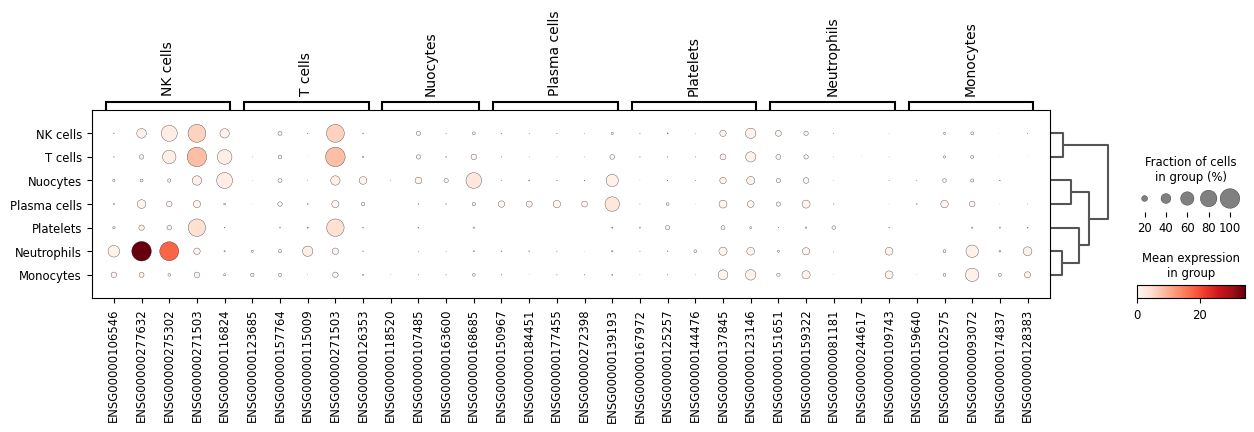

In [ ]:
sc.tl.dendrogram(bone_marrow_adata, groupby='cell_type')
sc.pl.dotplot(bone_marrow_adata, marker_genes_dict, "cell_type", dendrogram=True)

categories: 0, 1, 2, etc.
var_group_labels: T cells, Nuocytes, Neutrophils, etc.


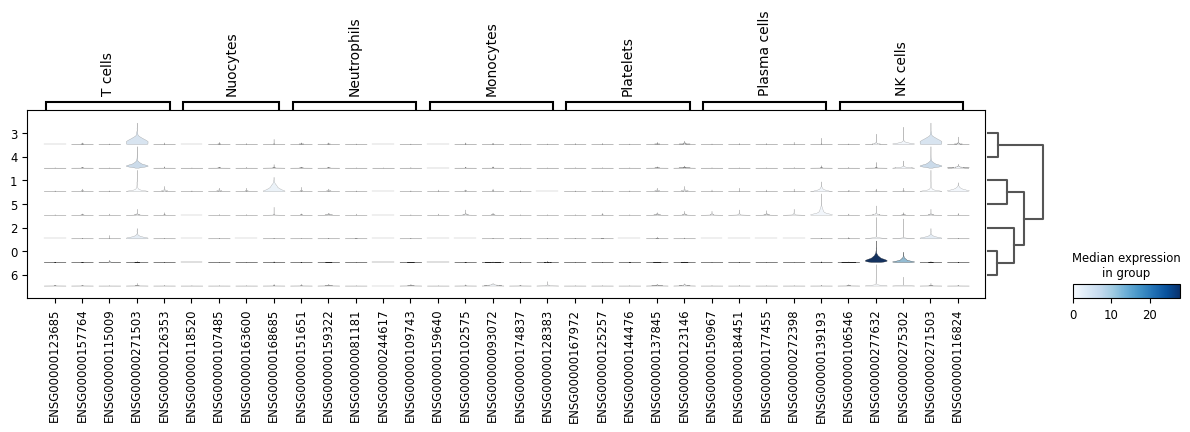

In [ ]:
sc.pl.stacked_violin(
    bone_marrow_adata, marker_genes_dict, groupby="leiden_res0_5",  dendrogram=True
)

categories: 0, 1
var_group_labels: T cells, Nuocytes, Neutrophils, etc.


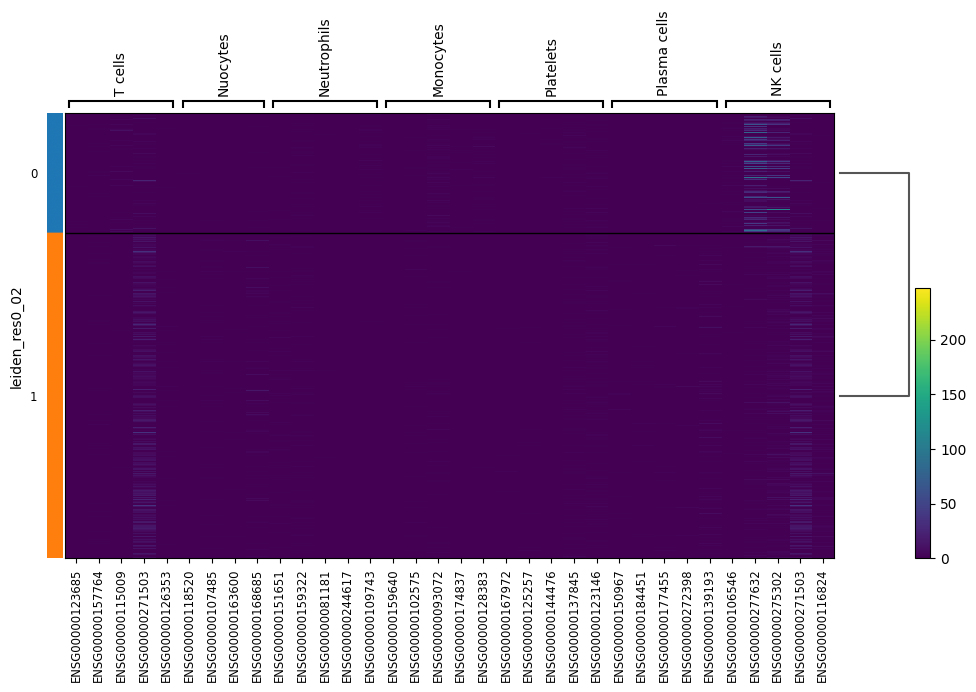

In [ ]:
sc.pl.heatmap(
    bone_marrow_adata, marker_genes_dict, groupby="leiden_res0_02", cmap="viridis", dendrogram=True
)

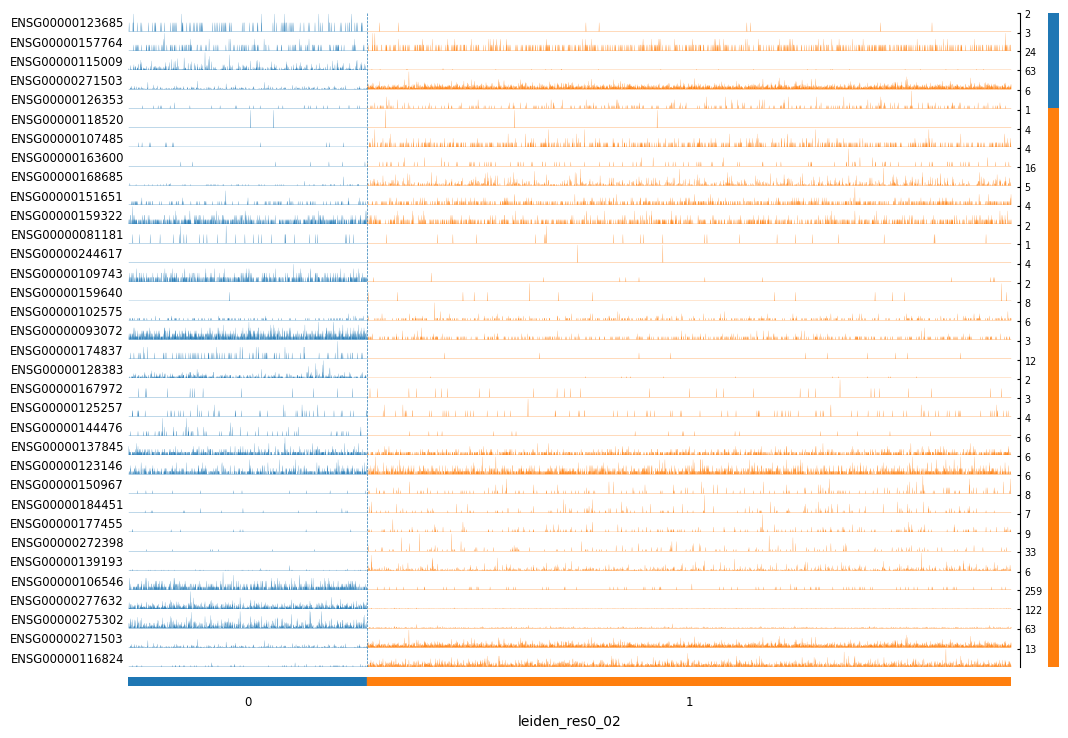

In [ ]:
# Using genome tracks
sc.pl.tracksplot(bone_marrow_adata, marker_genes_dict, groupby="leiden_res0_02", dendrogram=False)

A.  CELL TYPE IDENTIFICATION:
 Dominant Populations:
 1. Neutrophils
 2. Plasma Cells
 3. Plaletes
 4. Nuocytes
 5. T cells
 6. Monocytes
 7. Nk cells

Missing Populations: Erythoid Lineage, Megakaryocyte- erythoid progenitors, myeloid progenitors.
Interpretation: Mature immune cell landscape consistent with peripheral blood

B. Biological Role of Each Cell Type:

1. Neutrophils: active phagocytes that release enzymes to eliminate bacteria

2. Plasma cells: differentiated B-lymophocytes which secretes immunoglobin or antibodies

3. Plaletes: discoid, anuecleate cells that help in clot blood

4. Nuocytes: also known as type-2 innate lymphoid cells. They provide first line of defense against pathogens

5. T cells: responsible for cell-mediated immunity

6. Monocytes: innate immune cells that sere as key defenders and regulators in the immune system

7. Nk cells: rapid response cytotoxic lymphocytes that detect and eliminate abnormal cells


C. Tissue Origin Conclusion: Peripheral Blood Mononuclear Cell not Bone Marrow
Justification: Based on the absence of hallmark bone-marrow lineages (erythroid and megakaryocytic cells), the lack of detectable hematopoietic stem/progenitor (CD34+/KIT+) signatures, and a cell composition dominated by mature lymphocytes (T/B/NK) plus expected PBMC contaminants (dendritic cells, neutrophil fragments, plasma cells, platelets), this dataset represents PBMC / a PBMC-like preparation, not an unsorted bone-marrow sample.

According to Smith et al, 2025: Bone marrow functions as the central site of hematopoiesis, housing hematopoietic stem cells, lineage-committed progenitors, erythroid precursors, and megakaryocyte developmental stages. This environment also contains stromal cells, adipocytes, and a rich network of supportive niche cells, making bone marrow inherently heterogeneous and dominated by immature or differentiating cell types.
In contrast, peripheral blood contains only fully differentiated immune cells that have exited the bone marrow after maturation. Peripheral blood therefore lacks erythroid progenitors, megakaryocyte precursors, and early myeloid intermediates. Instead, it is populated by mature T cells, neutrophils, monocytes, NK cells, plasma cells, and circulating platelets. When these well-established differences are applied to the present dataset, the conclusion becomes unambiguous. The sample shows only mature immune cells—T cells, B cells, neutrophils, dendritic cells, monocytes, plasma cells, and platelets—and completely lacks hallmarks of bone marrow such as erythroid precursors, megakaryocyte lineage cells, hematopoietic stem cells, or immature granulocyte populations.
Therefore, this profile aligns with the immunological characteristics of peripheral blood, particularly under inflammatory conditions, and is incompatible with the composite, progenitor-rich architecture of bone marrow described in the paper. This dataset represents peripheral blood rather than bone marrow.

D. Based on the relative abundance of cell types, is the patient healthy or infected?

Neutrophils: Marked neutrophil expansion, which indicates hallmark of acute bacterial type inflammation. The neutrophil are first responders triggered by IL-8/G-CSF in infection. A large neutrophil cluster means the innate immune system is actively responding to pathogen-associated signals.
are
Monocytes:  Monocytes are also expanded and are involved in myeloid-driven inflammatory response. The monocyte compartment is also large, supporting the neutrophil signal, where emergency myelopoiesis is triggered.

NK cell activation states: Nk cells are present but appear moderate, which argues against a primarly viral progress.

Lymphocyte depletion or expansion: Lymphocyte expansion here is evident in plasma cells (B cell response) and stable T cell proportion, supporting an ongoing adaptive response to a pathogen.

Conclusion: The immune landscape shows meutrophils and monocytes expansin which indicates recruitment of phagocytes for pathogen clearance. Also, there is presence of both innate and adaptive immune response which signals an active infection.  The patient present an active infection.   